In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.fft import fft, fftfreq

In [3]:
df = pd.read_csv(r"C:\Users\Admin\Desktop\CP\Data\processed\final_processed\GAIT_analysis_dataset.csv")
df

,Patient ID,aSagH_0,aSagH_2,aSagH_4,aSagH_6,aSagH_8,aSagH_10,aSagH_12,aSagH_14,aSagH_16,...,aSagK_82,aSagK_84,aSagK_86,aSagK_88,aSagK_90,aSagK_92,aSagK_94,aSagK_96,aSagK_98,aSagK_100
0,1,34.489231,33.190099,31.611866,29.735892,27.653619,25.561388,23.659099,22.070589,20.809243,...,50.180644,48.361048,45.747773,42.545444,39.002017,35.373413,31.893023,28.766132,26.183560,24.284412
1,2,34.115943,33.845007,33.142873,32.425595,31.833842,31.200395,30.316142,29.124648,27.683478,...,36.856681,41.823153,45.755571,47.958314,48.090432,46.405582,43.682483,40.756274,38.099251,35.805094
2,3,46.266824,43.885923,41.490654,39.073092,36.650765,34.278363,32.022496,29.928085,27.998026,...,56.275353,53.910564,50.906875,47.310920,43.265528,39.025186,34.929357,31.336358,28.524134,26.583531
3,4,31.919585,29.332622,26.944135,24.833541,23.089692,21.746950,20.720097,19.807280,18.798043,...,56.399781,54.999984,52.696951,49.514561,45.606221,41.252328,36.805056,32.613890,28.952887,25.959657
4,5,34.398839,32.395244,30.418174,28.569600,26.850805,25.226143,23.697601,22.251928,20.845959,...,46.017507,42.047962,37.776869,33.473623,29.385098,25.673032,22.376516,19.419898,16.719602,14.333492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,CP152,42.429747,40.102682,36.755350,33.408856,30.922122,27.753506,24.640012,21.544426,18.561348,...,55.231592,53.383502,50.746365,47.185969,42.841141,37.997811,33.205888,28.943379,25.484040,22.766658
547,CP170,27.045223,26.060930,25.342578,24.680958,23.506208,21.747387,20.011563,18.636352,17.367513,...,55.361977,51.864558,47.604370,42.820967,37.690930,32.667078,28.316491,25.181901,23.573280,23.235346
548,CP195,43.094113,41.603654,40.014215,38.368341,36.680087,34.948594,33.165763,31.316489,29.379185,...,45.633593,41.745998,36.806451,31.039062,24.971145,19.298280,14.674303,11.439663,9.590914,9.137108
549,CP83,29.389849,28.819173,28.800633,28.806647,28.425304,27.505517,26.088310,24.249631,22.013928,...,42.732546,37.010111,31.439729,26.273291,21.687163,17.841182,14.871403,12.842567,11.731675,11.424054


In [4]:
df_stat = df.describe()

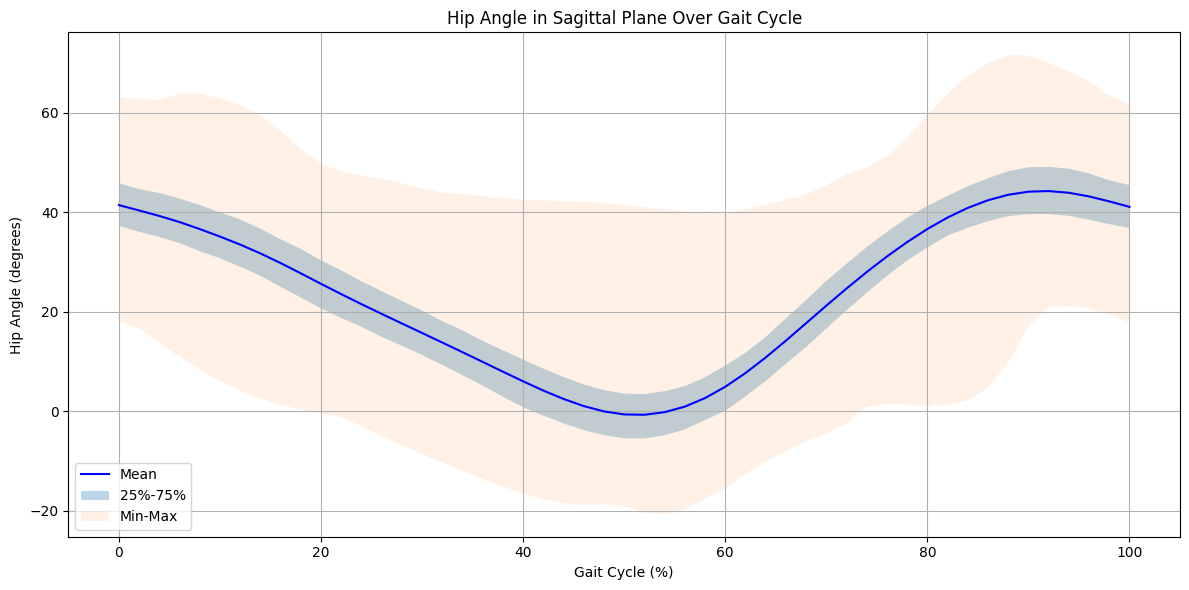

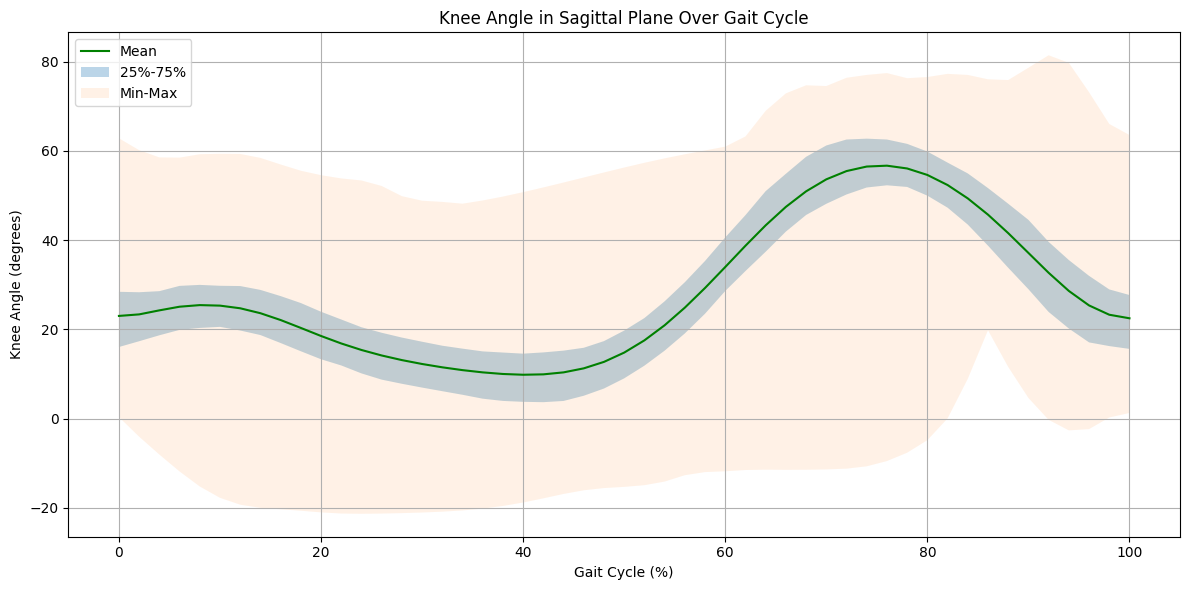

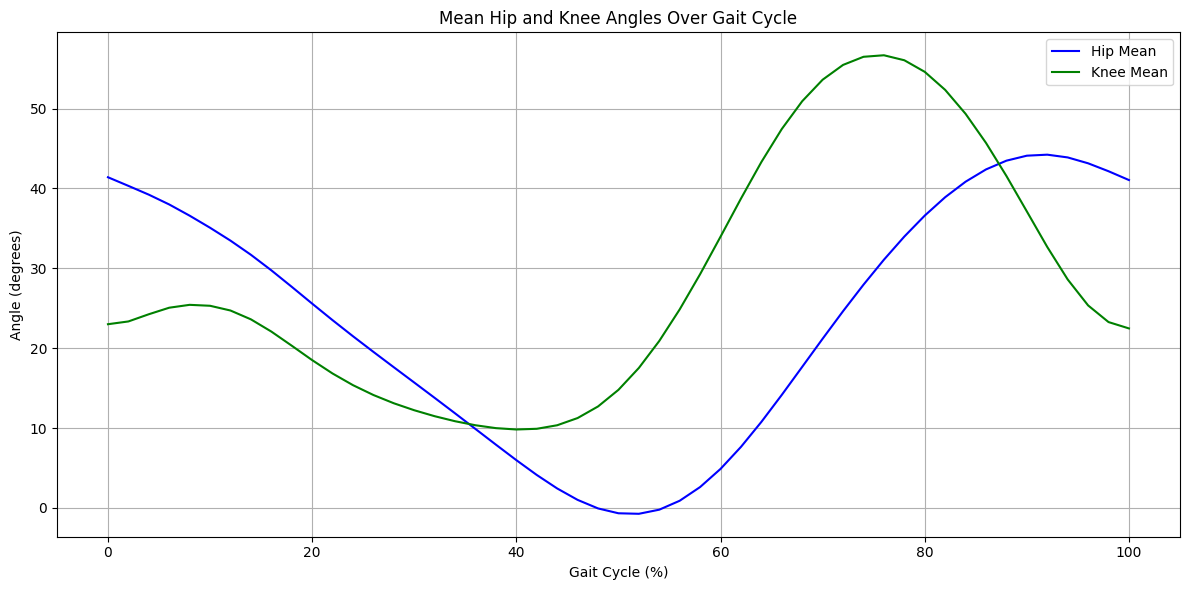

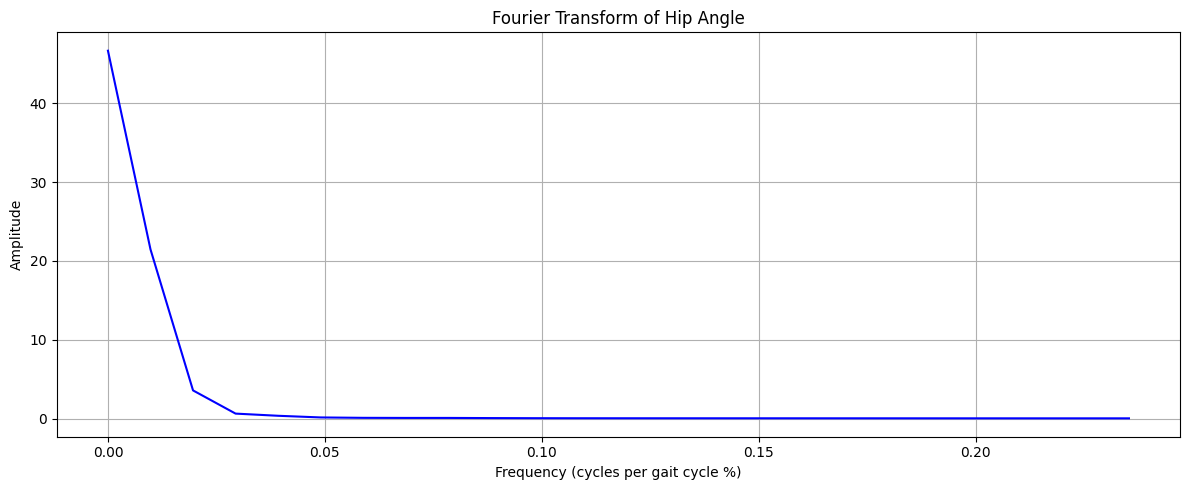

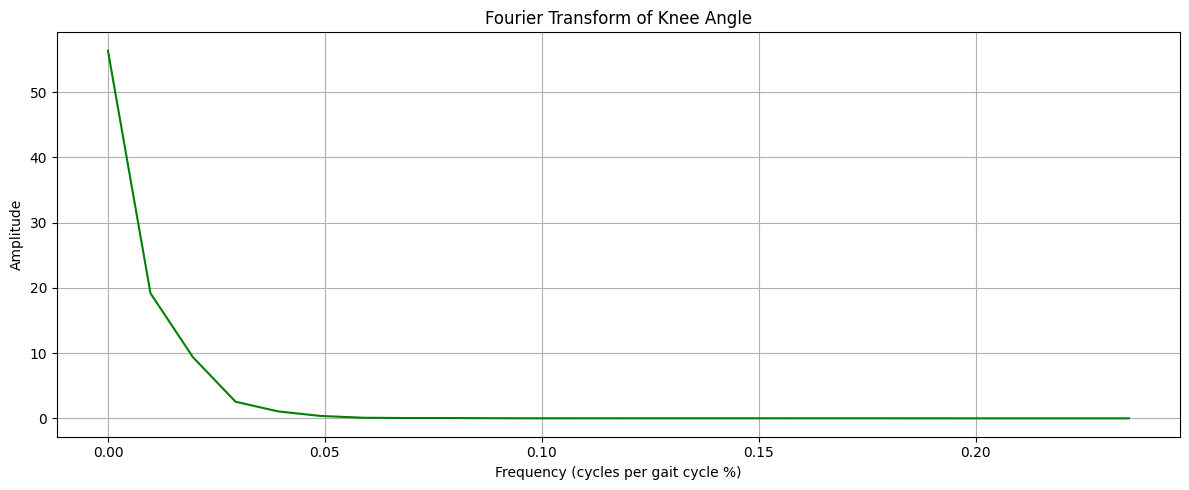

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Extract columns
hip_cols = sorted([col for col in df.columns if col.startswith('aSagH_')], key=lambda x: int(x.split('_')[-1]))
knee_cols = sorted([col for col in df.columns if col.startswith('aSagK_')], key=lambda x: int(x.split('_')[-1]))

# Extract gait cycle % from one of the column sets (assuming same for hip and knee)
gait_percent = [int(col.split('_')[-1]) for col in hip_cols]

# Convert to NumPy arrays
hip_data = df[hip_cols].to_numpy()
knee_data = df[knee_cols].to_numpy()

# Compute statistics
def compute_stats(data):
    return {
        'mean': np.nanmean(data, axis=0),
        'percentile_25': np.nanpercentile(data, 25, axis=0),
        'percentile_50': np.nanpercentile(data, 50, axis=0),
        'percentile_75': np.nanpercentile(data, 75, axis=0),
        'min': np.nanmin(data, axis=0),
        'max': np.nanmax(data, axis=0),
    }

hip_stats = compute_stats(hip_data)
knee_stats = compute_stats(knee_data)

# Plot 1: Hip angle with mean, IQR, and min-max
plt.figure(figsize=(12, 6))
plt.plot(gait_percent, hip_stats['mean'], label='Mean', color='blue')
plt.fill_between(gait_percent, hip_stats['percentile_25'], hip_stats['percentile_75'], alpha=0.3, label='25%-75%')
plt.fill_between(gait_percent, hip_stats['min'], hip_stats['max'], alpha=0.1, label='Min-Max')
plt.title("Hip Angle in Sagittal Plane Over Gait Cycle")
plt.xlabel("Gait Cycle (%)")
plt.ylabel("Hip Angle (degrees)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(gait_percent, knee_stats['mean'], label='Mean', color='green')
plt.fill_between(gait_percent, knee_stats['percentile_25'], knee_stats['percentile_75'], alpha=0.3, label='25%-75%')
plt.fill_between(gait_percent, knee_stats['min'], knee_stats['max'], alpha=0.1, label='Min-Max')
plt.title("Knee Angle in Sagittal Plane Over Gait Cycle")
plt.xlabel("Gait Cycle (%)")
plt.ylabel("Knee Angle (degrees)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Mean Hip vs Knee Angles
plt.figure(figsize=(12, 6))
plt.plot(gait_percent, hip_stats['mean'], label='Hip Mean', color='blue')
plt.plot(gait_percent, knee_stats['mean'], label='Knee Mean', color='green')
plt.title("Mean Hip and Knee Angles Over Gait Cycle")
plt.xlabel("Gait Cycle (%)")
plt.ylabel("Angle (degrees)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3: Fourier Transform
def plot_fft(signal, label, color, gait_percent):
    N = len(signal)
    T = gait_percent[1] - gait_percent[0]  # Assuming evenly spaced, like 1%
    
    yf = fft(signal)
    xf = fftfreq(N, T)[:N//2]
    
    plt.figure(figsize=(12, 5))
    plt.plot(xf, 2.0/N * np.abs(yf[:N//2]), color=color)
    plt.title(f"Fourier Transform of {label} Angle")
    plt.xlabel("Frequency (cycles per gait cycle %)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_fft(hip_stats['mean'], "Hip", "blue", gait_percent)
plot_fft(knee_stats['mean'], "Knee", "green", gait_percent)



Number of samples with NaNs: 1


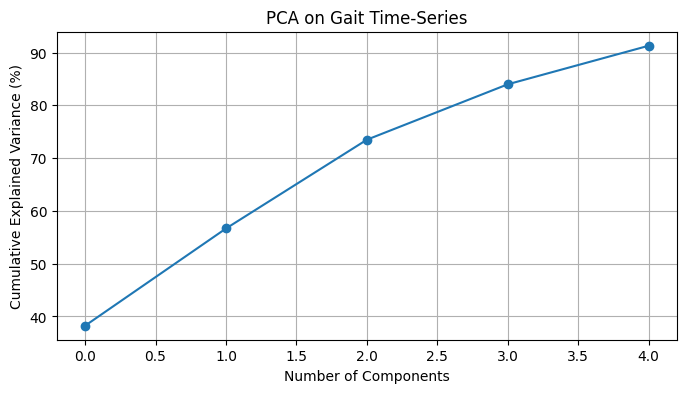

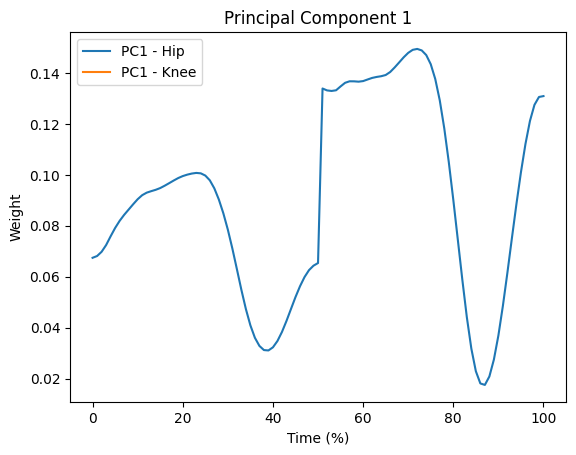

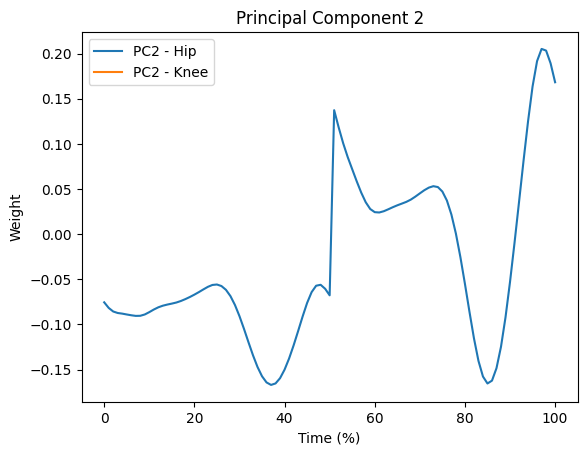

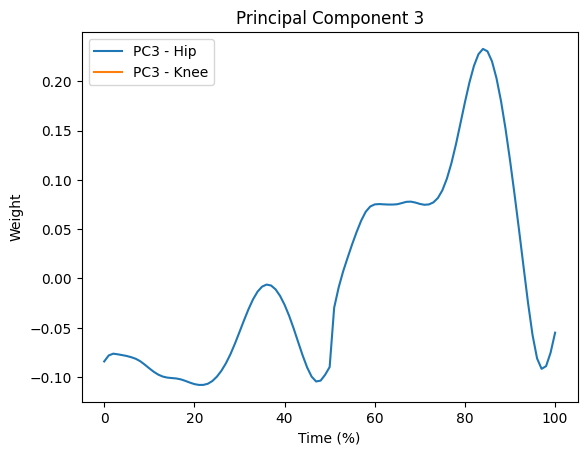

In [6]:
pca = PCA(n_components=5)

X = np.hstack([hip_data, knee_data])  # shape: (N, 2*T)
rows_with_nans = np.isnan(hip_data).any(axis=1) | np.isnan(knee_data).any(axis=1)
print(f"Number of samples with NaNs: {rows_with_nans.sum()}")
hip_clean = hip_data[~rows_with_nans]
knee_clean = knee_data[~rows_with_nans]
X = np.hstack([hip_clean, knee_clean])
X_pca = pca.fit_transform(X)

# 3. Explained Variance
plt.figure(figsize=(8,4))
plt.plot(np.nancumsum(pca.explained_variance_ratio_)*100, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA on Gait Time-Series')
plt.grid(True)
plt.show()

# 4. Optional: visualize first few PCs
for i in range(3):
    plt.plot(pca.components_[i][:101], label=f'PC{i+1} - Hip')
    plt.plot(pca.components_[i][101:], label=f'PC{i+1} - Knee')
    plt.title(f'Principal Component {i+1}')
    plt.xlabel('Time (%)')
    plt.ylabel('Weight')
    plt.legend()
    plt.show()

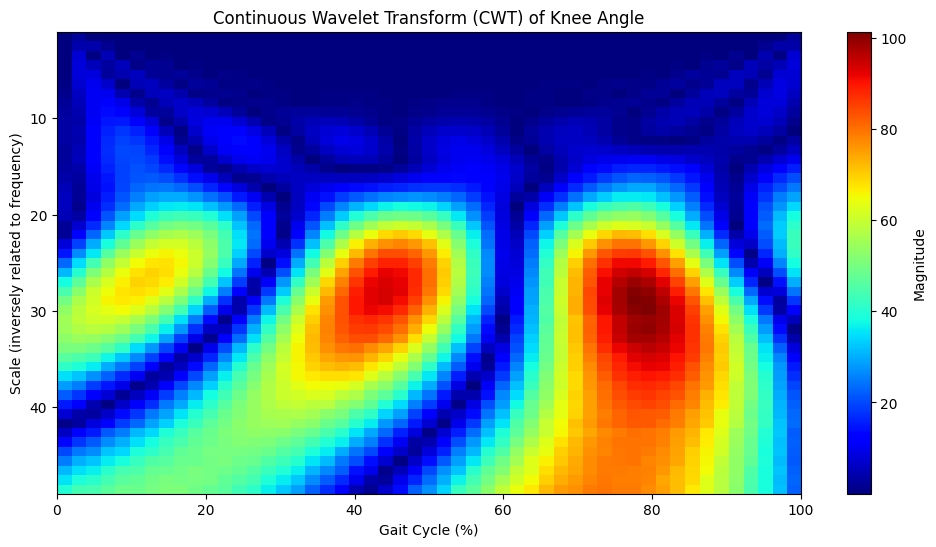

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# Simulated signal or your actual hip/knee angle array
signal = knee_stats["mean"] # or hip_mean
time = np.linspace(0, 100, len(signal))  # Gait cycle in %

# Choose scales (related to frequencies)
scales = np.arange(1, 50)

# Perform CWT using Morlet wavelet
coefficients, freqs = pywt.cwt(signal, scales, wavelet='morl')

# Plot
plt.figure(figsize=(12, 6))
plt.imshow(np.abs(coefficients), extent=[time[0], time[-1], scales[-1], scales[0]],
           cmap='jet', aspect='auto')
plt.colorbar(label='Magnitude')
plt.xlabel('Gait Cycle (%)')
plt.ylabel('Scale (inversely related to frequency)')
plt.title('Continuous Wavelet Transform (CWT) of Knee Angle')
plt.show()


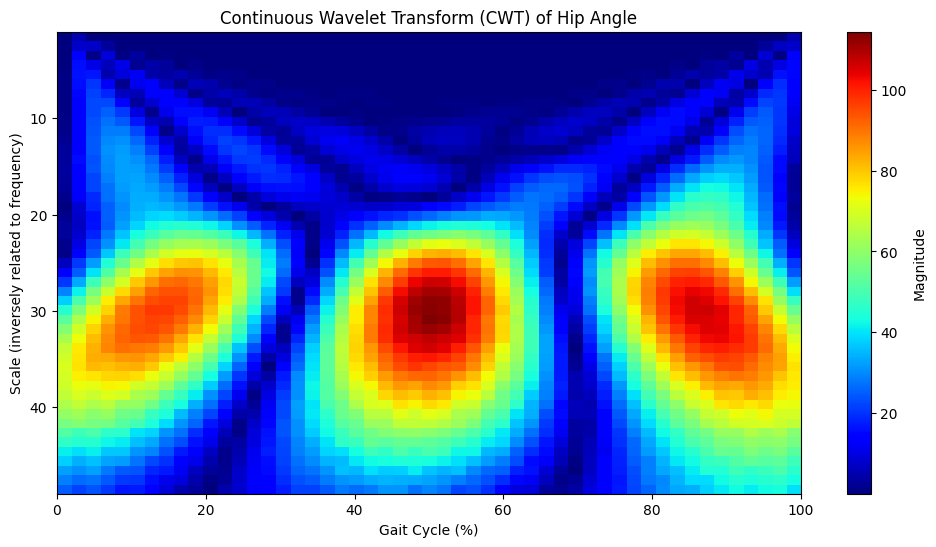

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# Simulated signal or your actual hip/knee angle array
signal = hip_data # or hip_mean
time = np.linspace(0, 100, len(signal))  # Gait cycle in %

# Choose scales (related to frequencies)
scales = np.arange(1, 50)

# Perform CWT using Morlet wavelet
coefficients, freqs = pywt.cwt(signal, scales, wavelet='morl')

# Plot
plt.figure(figsize=(12, 6))
plt.imshow(np.abs(coefficients), extent=[time[0], time[-1], scales[-1], scales[0]],
           cmap='jet', aspect='auto')
plt.colorbar(label='Magnitude')
plt.xlabel('Gait Cycle (%)')
plt.ylabel('Scale (inversely related to frequency)')
plt.title('Continuous Wavelet Transform (CWT) of Hip Angle')
plt.show()

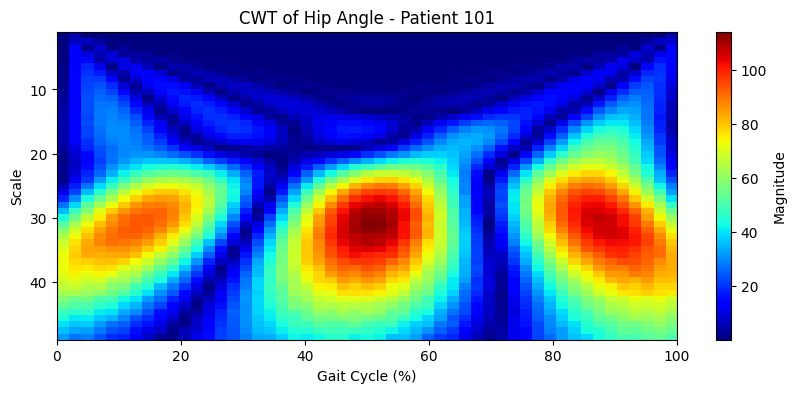

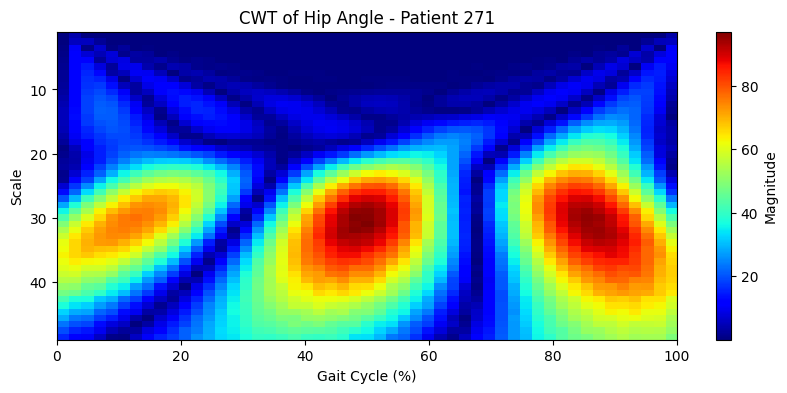

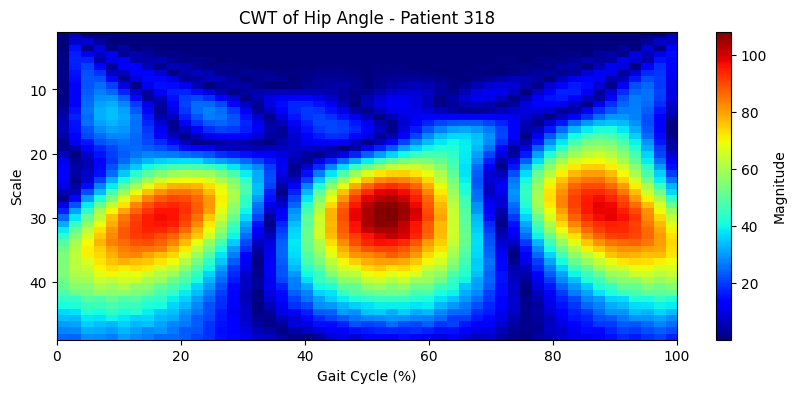

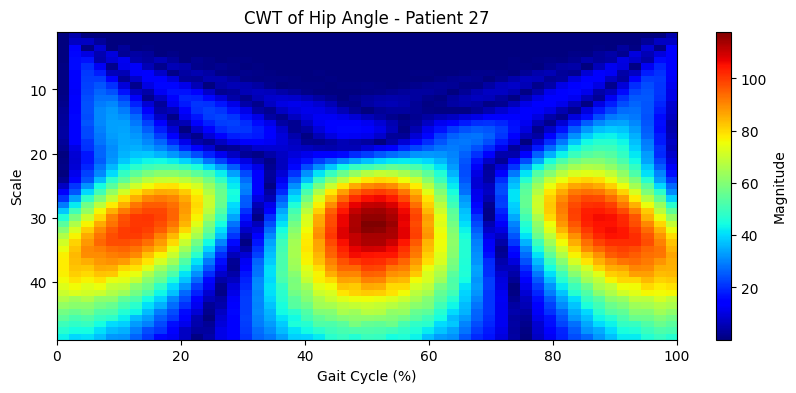

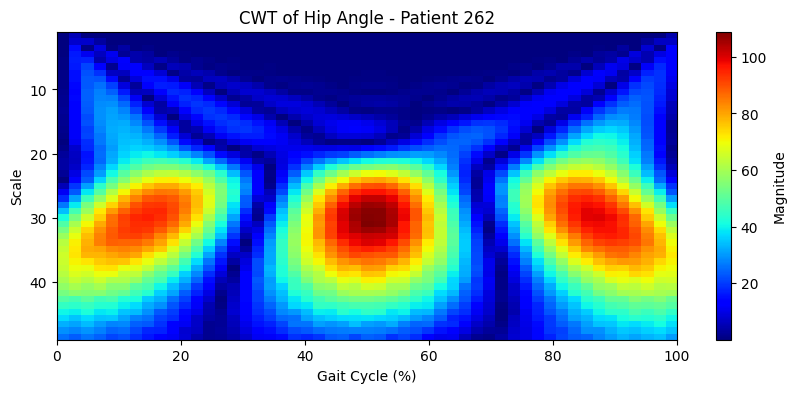

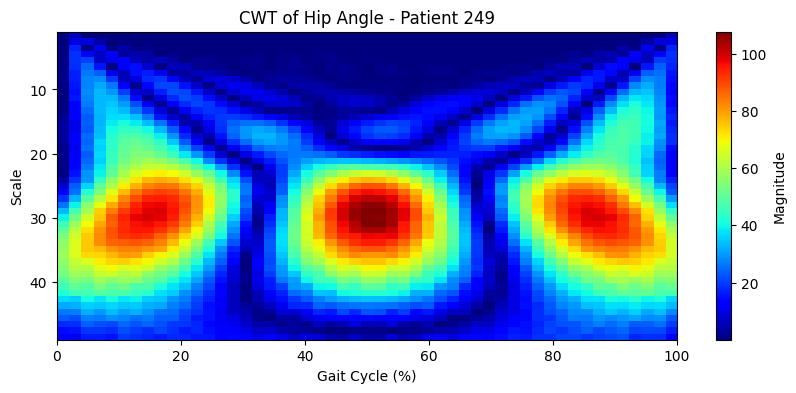

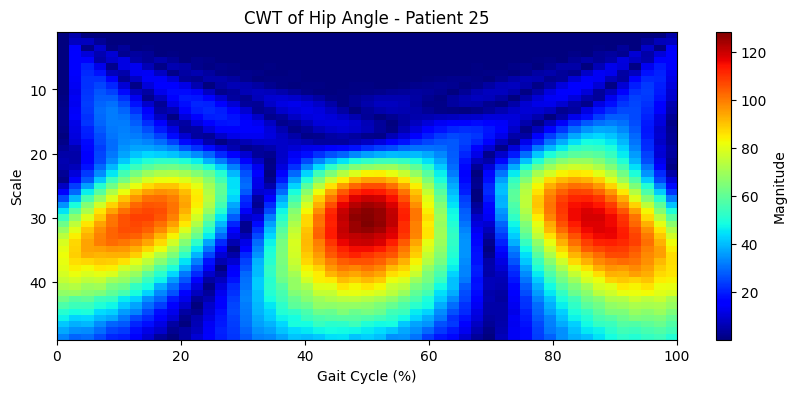

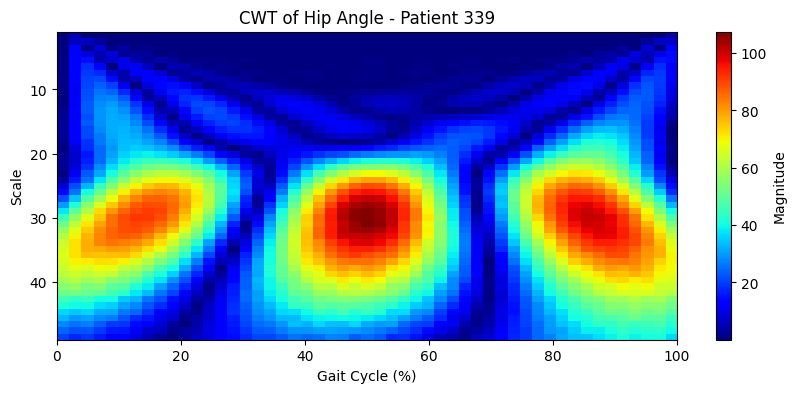

In [13]:
for i in range(8):
    idx = np.random.randint(0, hip_data.shape[0])
    signal = hip_data[idx]
    
    time = np.linspace(0, 100, len(signal))
    scales = np.arange(1, 50)
    coefficients, freqs = pywt.cwt(signal, scales, wavelet='morl')
    
    plt.figure(figsize=(10, 4))
    plt.imshow(np.abs(coefficients), extent=[time[0], time[-1], scales[-1], scales[0]],
               cmap='jet', aspect='auto')
    plt.colorbar(label='Magnitude')
    plt.xlabel('Gait Cycle (%)')
    plt.ylabel('Scale')
    plt.title(f'CWT of Hip Angle - Patient {idx}')
    plt.show()


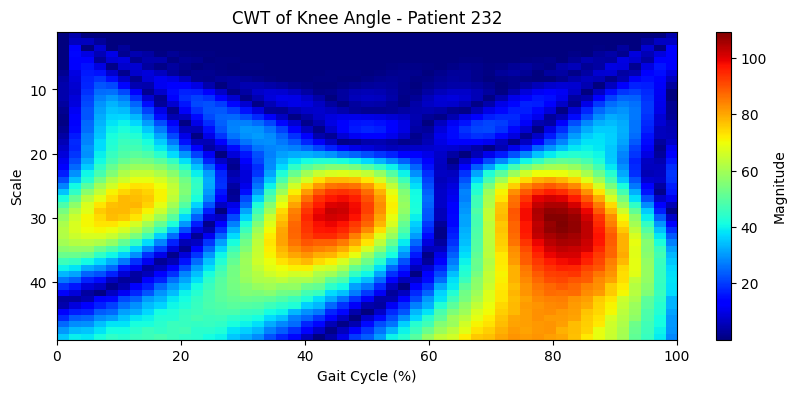

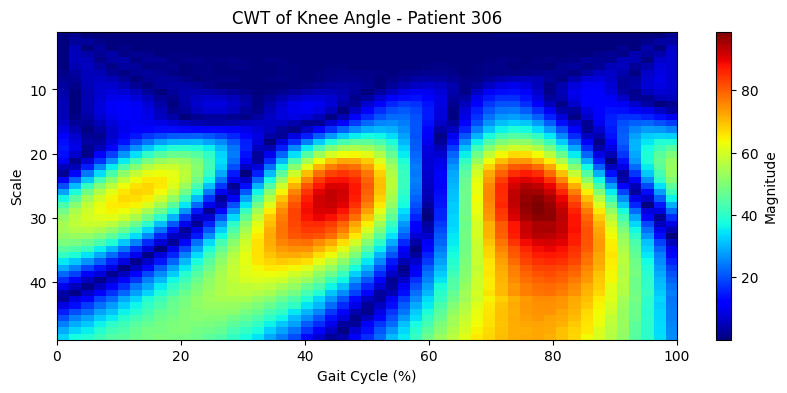

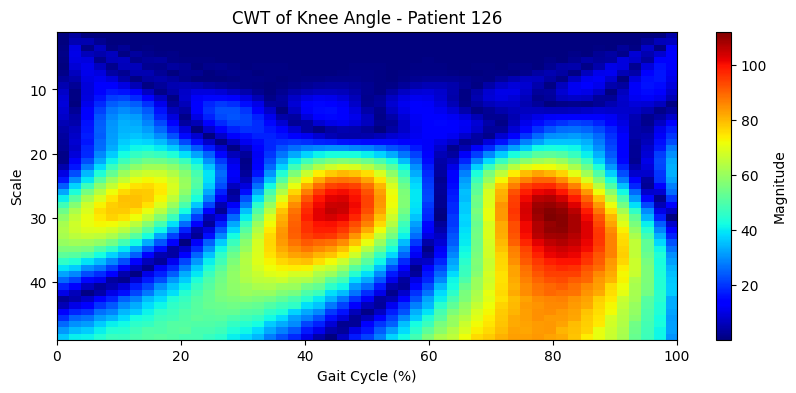

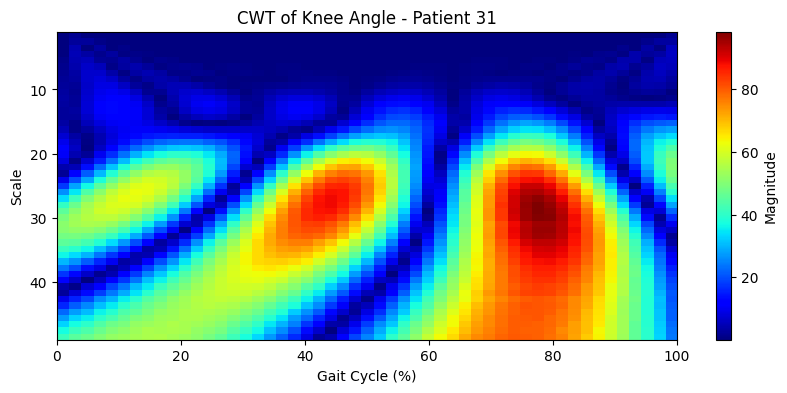

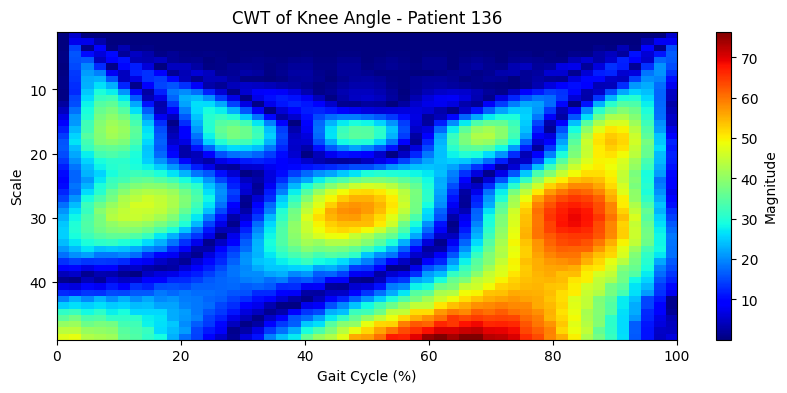

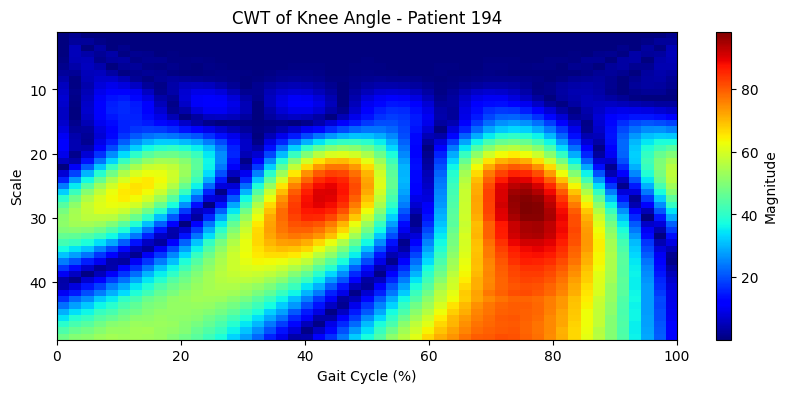

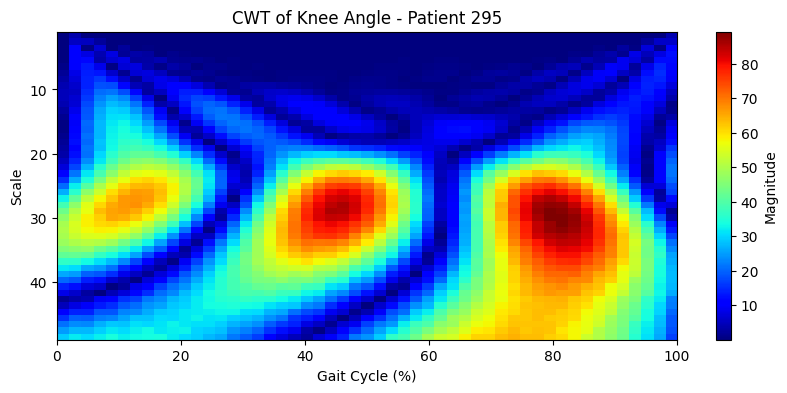

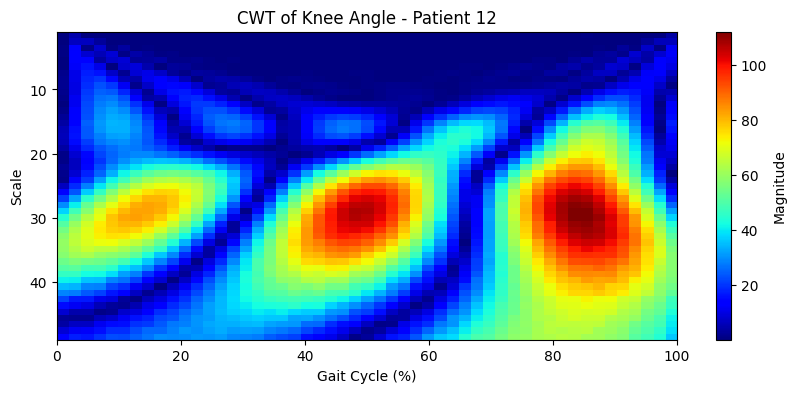

In [14]:
for i in range(8):
    idx = np.random.randint(0, hip_data.shape[0])
    signal = knee_data[idx]
    
    time = np.linspace(0, 100, len(signal))
    scales = np.arange(1, 50)
    coefficients, freqs = pywt.cwt(signal, scales, wavelet='morl')
    
    plt.figure(figsize=(10, 4))
    plt.imshow(np.abs(coefficients), extent=[time[0], time[-1], scales[-1], scales[0]],
               cmap='jet', aspect='auto')
    plt.colorbar(label='Magnitude')
    plt.xlabel('Gait Cycle (%)')
    plt.ylabel('Scale')
    plt.title(f'CWT of Knee Angle - Patient {idx}')
    plt.show()
